# Praktikum 7 - Jaringan Syaraf Tiruan 2

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
# Muat dataset iris dari file lokal
dataset = pd.read_csv('iris.data', header=None, sep=',')

# Menyusun data X (fitur) dan y (label)
X = dataset.iloc[:, :-1].values  # 4 kolom pertama sebagai fitur
y = dataset.iloc[:, -1].values   # Kolom terakhir sebagai label

In [ ]:
# Mengonversi label dari string menjadi numerik
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)  # Mengubah label jadi 0, 1, 2

In [ ]:
# Memisahkan dataset menjadi data latih dan data validasi dengan rasio 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = Sequential([
    Input(shape=X_train.shape[1:]),
    Dense(1000, activation='relu'),
    Dense(500, activation='relu'),
    Dense(300, activation='relu'),
    Dense(3, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1000)           │         5,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 300)            │       150,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 656,703 (2.51 MB)

 Trainable params: 656,703 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.5333 - loss: 1.0000 - val_accuracy: 0.4667 - val_loss: 0.8274
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7833 - loss: 0.6171 - val_accuracy: 0.7667 - val_loss: 0.4343
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9000 - loss: 0.3972 - val_accuracy: 0.8667 - val_loss: 0.3125
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9667 - loss: 0.2630 - val_accuracy: 0.9667 - val_loss: 0.2275
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9500 - loss: 0.1939 - val_accuracy: 0.8667 - val_loss: 0.2274
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9083 - loss: 0.1918 - val_accuracy: 0.8667 - val_loss: 0.2248
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9250 - loss: 0.1622 - val_accuracy: 0.9000 - val_loss: 0.2016
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9083 - loss: 0.1631 - val_accuracy: 0.8667 - val_loss: 0.2948

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9667 - loss: 0.0759
Loss: 0.07586674392223358, Accuracy: 0.9666666388511658


<Axes: >

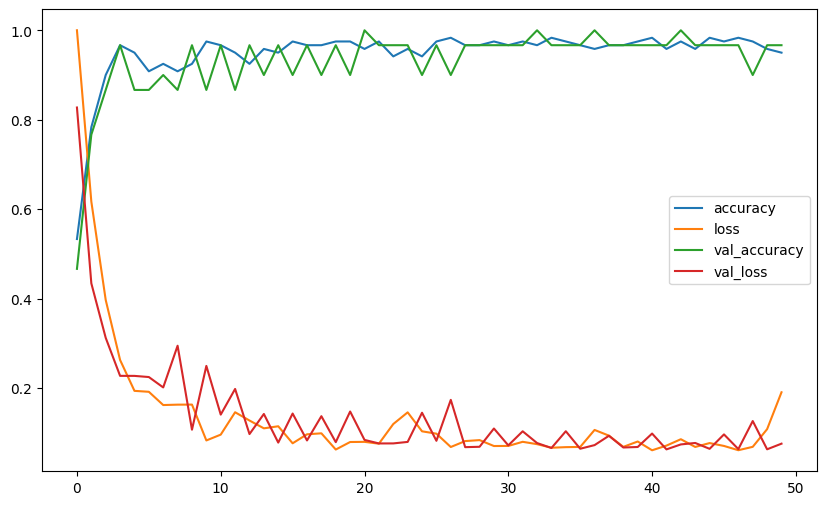

In [9]:
pd.DataFrame(history.history).plot(figsize=(10,6))

In [10]:
predictions = model.predict(X_test)
# Mengambil indeks dari nilai probabilitas tertinggi untuk setiap prediksi
predicted_classes = predictions.argmax(axis=1)
print("Prediksi:", predicted_classes)
print("Label Asli:", y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Prediksi: [1 0 2 1 1 0 1 2 2 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Label Asli: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


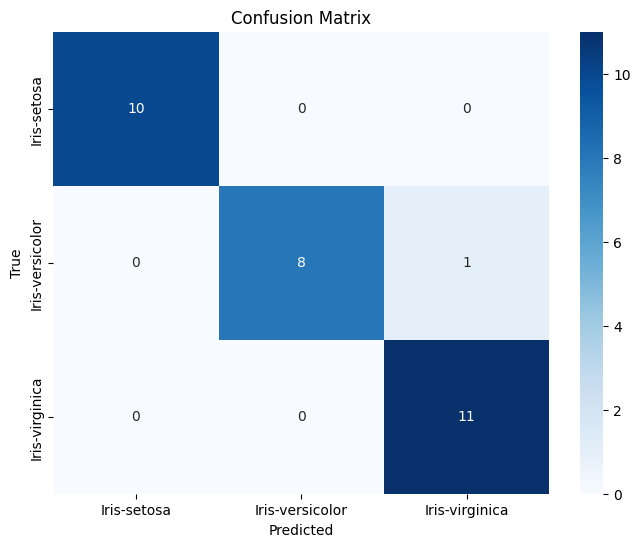

In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Buat confusion matrix
cm = confusion_matrix(y_test, predicted_classes)

# Visualisasikan confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [12]:
# Fungsi untuk memprediksi data input baru
def predict_new_data():
    sepal_length = float(input("Masukkan sepal length: "))
    sepal_width = float(input("Masukkan sepal width: "))
    petal_length = float(input("Masukkan petal length: "))
    petal_width = float(input("Masukkan petal width: "))

    # Membuat data array baru
    new_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

    # Melakukan prediksi
    prediction = model.predict(new_data)
    predicted_class = prediction.argmax(axis=1)

    # Mengonversi hasil prediksi numerik menjadi label asli
    predicted_label = label_encoder.inverse_transform(predicted_class)
    print(f"Prediksi kelas: {predicted_label[0]}")

predict_new_data()

ValueError: could not convert string to float: ''